# Lecture 5 code-along — Inside an MLP forward pass

We will compute a neuron, a layer, and a two-hidden-layer MLP by hand,
validate the answers in NumPy, and then train a digit classifier.

## Goal

By the end, you should be able to:

1. calculate a forward pass from given weights and biases;
2. explain how a neuron is related to a linear model;
3. read a small MLP directly from NumPy code;
4. connect that code to a trained scikit-learn model.

> neuron → layer → two hidden layers → output scores → trained digit model

## Setup

Core libraries: NumPy, Matplotlib, and scikit-learn. Run one cell at a time.
**Do the small calculation on paper before running its answer cell.**

In [26]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

np.set_printoptions(precision=3, suppress=True)
BLUE = "#2563EB"
ORANGE = "#F97316"

## Part A — Build the forward pass from small pieces

A biological neuron inspired the name, but an artificial neuron is a much
simpler mathematical object:

> inputs → weighted sum + bias → activation → output

Start with numbers that are easy enough to calculate by hand.

### 1. One neuron is a linear model plus an activation

The familiar linear calculation is `inputs @ weights + bias`. ReLU then
keeps positive values and replaces negative values with zero.

**By hand:** for `inputs = [1, 2]`, `weights = [1, 2]`, and `bias = 0`,
calculate the score and the ReLU output.

In [37]:
# Type these two reusable building blocks.
def dense(inputs, weights, bias):
    return inputs @ weights + bias

"""
def -- we just define a function (take input, return output)
def dense(X, W, B):
  return X @ W + B --- a linear model , we need a non-linearity to make it a layer

def relu(X):
  return np.maximum(0, X)

def sigmoid(X):
  return 1 (1 + np.exp(-x))

"""

def relu(values):
    return np.maximum(0, values)

In [36]:
# broadcasting

x1 = np.array([[1,2,3],
               [-1,0,2]])

x2 = np.array([4, 1, 0])


x1.shape, x2.shape
# x1 + x2

((2, 3), (3,))

In [39]:
# X = [1, 2] W = [1, 2]
# [a, b] @ [c, d] = ac + bd
# [1, 2] @ [1, 2] = 1* 1 + 2* 2 = 5 + 0 = 5
# relu(5) = 5

one_input = np.array([1, 2])
one_neuron_weights = np.array([1, 2])
one_neuron_bias = 0

one_score = dense(one_input, one_neuron_weights, one_neuron_bias)
one_output = relu(one_score)

print("score before ReLU:", one_score)
print("output after ReLU:", one_output)

score before ReLU: 5
output after ReLU: 5


In [41]:
# consider 5 digist (0,1,2,3,4)
scores = np.array([0, 3.2, 2.2, 8, 3.5])

np.argmax(scores) # first it find the maximum ~ 8 , then returns the index of 8 - 3


np.int64(3)

The answer is `5`: `1×1 + 2×2 + 0 = 5`, and `ReLU(5) = 5`.

- Inputs came from the example.
- Weights and bias are model parameters.
- The activation decides what is sent to the next layer.

### 2. One layer repeats the neuron calculation

We will process two examples at once and use three neurons.

- `X_small` has shape `(2, 2)`: two examples, two input features.
- `W1` has shape `(2, 3)`: two incoming features, three neurons.
- `b1` has shape `(3,)`: one bias for each neuron.

**Before running:** calculate the first output row of `X_small @ W1 + b1`.

In [4]:
X_small = np.array([
    [1,  2],
    [0, -1],
])

W1 = np.array([
    [1, -1,  0],
    [2,  1, -2],
])
b1 = np.array([0, 1, 0])

print("X_small shape:", X_small.shape)
print("W1 shape:     ", W1.shape)
print("b1 shape:     ", b1.shape)

X_small shape: (2, 2)
W1 shape:      (2, 3)
b1 shape:      (3,)


In [5]:
Z1 = dense(X_small, W1, b1)

print("Z1 before ReLU:\n", Z1)
print("Z1 shape:", Z1.shape)

Z1 before ReLU:
 [[ 5  2 -4]
 [-2  0  2]]
Z1 shape: (2, 3)


You should obtain:

```text
[[ 5, 2, -4],
 [-2, 0,  2]]
```

Each row belongs to one example. Each column belongs to one neuron.

### 3. ReLU creates the first hidden representation

**Before running:** cross out each negative number in `Z1` and replace it
with zero. The result is called `H1`.

In [6]:
H1 = relu(Z1)

print("H1 after ReLU:\n", H1)
print("H1 shape:", H1.shape)

H1 after ReLU:
 [[5 2 0]
 [0 0 2]]
H1 shape: (2, 3)


### 4. Add a second hidden layer

The new layer treats `H1` as its input. Nothing fundamentally new happens:

> matrix multiplication + bias → ReLU

**Before running:** calculate the bottom row of `H1 @ W2 + b2`.

In [7]:
W2 = np.array([
    [ 1, 0],
    [ 0, 1],
    [-1, 1],
])
b2 = np.array([0, 1])

Z2 = dense(H1, W2, b2)
H2 = relu(Z2)

print("Z2 before ReLU:\n", Z2)
print("H2 after ReLU:\n", H2)

Z2 before ReLU:
 [[ 5  3]
 [-2  3]]
H2 after ReLU:
 [[5 3]
 [0 3]]


### 5. The output layer produces class scores

The output layer has two neurons because our tiny example has two possible
classes. We choose the largest score with `argmax`.

The output layer does not use ReLU here. A classifier can turn these scores
into probabilities afterward.

In [8]:
W3 = np.array([
    [1, -1],
    [0,  1],
])
b3 = np.array([0, 0])

scores = dense(H2, W3, b3)
predictions_small = np.argmax(scores, axis=1)

print("class scores:\n", scores)
print("predicted classes:", predictions_small)

class scores:
 [[ 5 -2]
 [ 0  3]]
predicted classes: [0 1]


### 6. Put the complete forward pass in one function

Read this function as a direct translation of the mathematical steps.

In [9]:
def two_hidden_layer_forward(inputs, W1, b1, W2, b2, W3, b3):
    Z1 = dense(inputs, W1, b1)
    H1 = relu(Z1)
    Z2 = dense(H1, W2, b2)
    H2 = relu(Z2)
    scores = dense(H2, W3, b3)
    return scores


scores_again = two_hidden_layer_forward(
    X_small, W1, b1, W2, b2, W3, b3
)
print(scores_again)

[[ 5 -2]
 [ 0  3]]


In [10]:
# These checks confirm the hand calculation and the complete function.
assert np.array_equal(Z1, np.array([[5, 2, -4], [-2, 0, 2]]))
assert np.array_equal(H1, np.array([[5, 2, 0], [0, 0, 2]]))
assert np.array_equal(Z2, np.array([[5, 3], [-2, 3]]))
assert np.array_equal(H2, np.array([[5, 3], [0, 3]]))
assert np.array_equal(scores_again, np.array([[5, -2], [0, 3]]))
assert np.array_equal(predictions_small, np.array([0, 1]))
print("✓ NumPy matches every hand-calculated value")

✓ NumPy matches every hand-calculated value


### Interactive check

Open [Google's neuron and hidden-layer interactive](https://developers.google.com/machine-learning/crash-course/neural-networks/nodes-hidden-layers).

1. Predict the output before pressing play.
2. Change one input, weight, or bias.
3. Add a hidden layer and trace which later values change.

In [11]:
# Visualization helper: you do not need to understand this plotting code yet.
def show_digits(images, true_labels, title, predicted_labels=None):
    count = min(len(images), 12)
    fig, axes = plt.subplots(2, 6, figsize=(11, 4.2))
    for position, axis in enumerate(axes.ravel()):
        if position >= count:
            axis.axis("off")
            continue
        axis.imshow(images[position], cmap="gray_r", vmin=0, vmax=16)
        if predicted_labels is None:
            text = f"label {true_labels[position]}"
        else:
            text = f"true {true_labels[position]} | pred {predicted_labels[position]}"
        axis.set_title(text, fontsize=10)
        axis.axis("off")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()


def show_loss(loss_values):
    epochs = np.arange(1, len(loss_values) + 1)
    plt.figure(figsize=(7, 3.8))
    plt.plot(epochs, loss_values, color=BLUE, linewidth=2.5)
    plt.xlabel("training step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## Part B — Scale the same forward pass up to handwritten digits

### 7. Load and look at the data

`load_digits()` gives us images and their correct digit labels.

**Predict first:** What shape should 1,797 images of size 8×8 have?

In [12]:
# Type this cell with me.
digits = load_digits()

print("images:", digits.images.shape)
print("flattened data:", digits.data.shape)
print("labels:", digits.target.shape)
print("pixel range:", digits.data.min(), "to", digits.data.max())

images: (1797, 8, 8)
flattened data: (1797, 64)
labels: (1797,)
pixel range: 0.0 to 16.0


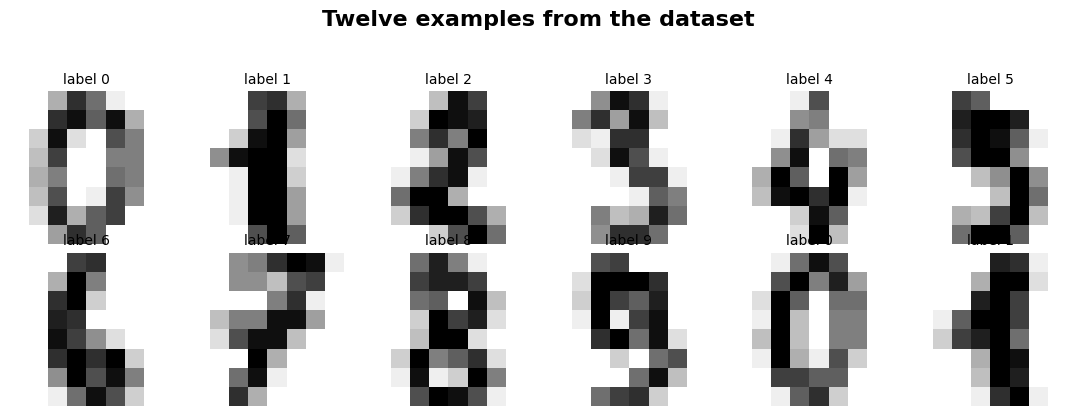

In [13]:
show_digits(
    digits.images[:12],
    digits.target[:12],
    "Twelve examples from the dataset",
)

### 8. Create `X` and `y`

This reconnects to our first lectures:

- `X` is a matrix: one example per row, one pixel per column.
- `y` is a vector: one correct answer per row.
- Dividing by 16 changes pixels from 0–16 to 0–1.

In [14]:
# Type these two important lines.
X = digits.data / 16.0 # normalization
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("one row shape:", X[0].shape)
print("new pixel range:", X.min(), "to", X.max())

X shape: (1797, 64)
y shape: (1797,)
one row shape: (64,)
new pixel range: 0.0 to 1.0


### 9. Keep test examples separate

The model learns only from the training rows. The test rows provide a final,
more honest check.

In [15]:
# Type the split with me.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("training:", X_train.shape, y_train.shape)
print("test:    ", X_test.shape, y_test.shape)

training: (1437, 64) (1437,)
test:     (360, 64) (360,)


### 10. Create a two-hidden-layer model

`hidden_layer_sizes=(32, 16)` means:

> 64 pixel inputs → 32 hidden neurons → 16 hidden neurons → 10 digit outputs

ReLU supplies the non-linearity we studied in Lecture 4.

In [16]:
# Type the complete model definition.
digit_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=400,
    random_state=42,
)

print(digit_model)

MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=400, random_state=42)


### 11. Train the model

One line hides the loop we already learned:

> forward pass → loss → backpropagation → parameter update → repeat

The images stay fixed. The model's weights and biases change.

In [17]:
# This starts with fresh random parameters and learns from the training rows.
digit_model.fit(X_train, y_train)

print("training steps:", digit_model.n_iter_)
print("final training loss:", round(digit_model.loss_, 4))

training steps: 345
final training loss: 0.0049


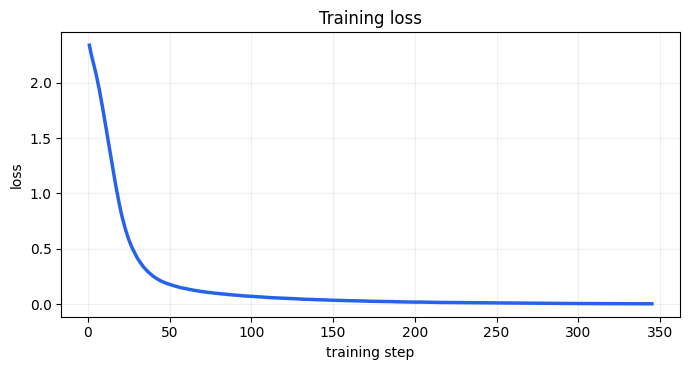

In [18]:
show_loss(digit_model.loss_curve_)

### 12. Use the learned model

`predict` performs a forward pass. It does **not** update the parameters.

In [19]:
test_predictions = digit_model.predict(X_test)
test_accuracy = digit_model.score(X_test, y_test)

print("first ten predictions:", test_predictions[:10])
print("first ten answers:    ", y_test[:10])
print("test accuracy:", f"{test_accuracy:.1%}")

first ten predictions: [5 2 8 1 7 2 6 2 6 5]
first ten answers:     [5 2 8 1 7 2 6 2 6 5]
test accuracy: 97.2%


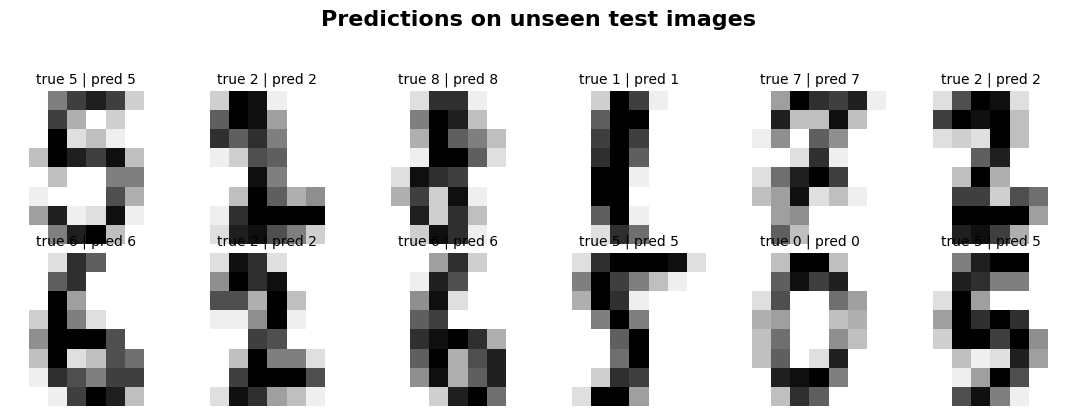

In [20]:
show_digits(
    X_test[:12].reshape(-1, 8, 8) * 16.0,
    y_test[:12],
    "Predictions on unseen test images",
    predicted_labels=test_predictions[:12],
)

### 13. Connect the code to learned parameters

Every connection is a learned weight. Every neuron has a learned bias.
Lecture 6 will inspect these matrices more carefully.

In [21]:
print("weight matrix shapes:", [matrix.shape for matrix in digit_model.coefs_])
print("bias vector shapes:  ", [vector.shape for vector in digit_model.intercepts_])

weight matrix shapes: [(64, 32), (32, 16), (16, 10)]
bias vector shapes:   [(32,), (16,), (10,)]


#### Validate one scikit-learn forward pass ourselves

`fit` learned much larger versions of `W1`, `b1`, `W2`, and `b2`.
We can take one test image through those matrices using the same NumPy steps.

For ten-class classification, the final `softmax` converts scores into
probabilities that add to one.

In [22]:
def softmax(scores):
    shifted_scores = scores - scores.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted_scores)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


one_image = X_test[:1]
manual_H1 = relu(
    one_image @ digit_model.coefs_[0] + digit_model.intercepts_[0]
)
manual_H2 = relu(
    manual_H1 @ digit_model.coefs_[1] + digit_model.intercepts_[1]
)
manual_scores = (
    manual_H2 @ digit_model.coefs_[2] + digit_model.intercepts_[2]
)
manual_probabilities = softmax(manual_scores)
library_probabilities = digit_model.predict_proba(one_image)

print("manual probabilities: ", manual_probabilities.round(4))
print("library probabilities:", library_probabilities.round(4))
print("same result:", np.allclose(manual_probabilities, library_probabilities))

manual probabilities:  [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
library probabilities: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
same result: True


In [23]:
assert manual_H1.shape == (1, 32)
assert manual_H2.shape == (1, 16)
assert manual_scores.shape == (1, 10)
assert np.allclose(manual_probabilities, library_probabilities)
print("✓ The trained library model uses the same forward-pass operations")

✓ The trained library model uses the same forward-pass operations


### 14. Change one thing and train again

**Predict first:** Will a smaller model always produce the same score?

In [24]:
smaller_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    max_iter=800,
    random_state=42,
)
smaller_model.fit(X_train, y_train)

print("(16, 8) accuracy:", f"{smaller_model.score(X_test, y_test):.1%}")
print("(32, 16) accuracy:", f"{test_accuracy:.1%}")

(16, 8) accuracy: 96.7%
(32, 16) accuracy: 97.2%


## Checks

Explain these before looking back:

1. Calculate `inputs @ weights + bias` for one neuron.
2. Explain why the columns of a weight matrix correspond to neurons.
3. Trace `X → Z1 → H1 → Z2 → H2 → scores`.
4. Explain what `(32, 16)` describes.
5. Explain what changes during `fit`.
6. State the difference between `fit` and `predict`.

In [25]:
assert X.shape == (1797, 64)
assert np.array_equal(predictions_small, np.array([0, 1]))
assert len(digit_model.coefs_) == 3
assert np.allclose(manual_probabilities, library_probabilities)
assert test_predictions.shape == y_test.shape
assert test_accuracy > 0.90
print("✓ The hand calculation and complete training workflow work")

✓ The hand calculation and complete training workflow work


## Next steps

In Lecture 6, rebuild this model without copying. Then add a pipeline,
validation, detailed evaluation, saving, and a small app.